# Lấy Lịch Sử Giao Dịch từ Bitget API

Notebook này hướng dẫn cách lấy dữ liệu lịch sử giao dịch từ Bitget API với các giới hạn sau:
- Tối đa 10 yêu cầu/giây cho mỗi IP
- Dữ liệu có sẵn trong 90 ngày gần nhất
- Khoảng thời gian giữa startTime và endTime không quá 7 ngày

In [14]:
# Import các thư viện cần thiết
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
from datetime import datetime, timedelta
import seaborn as sns
from IPython.display import display

## Cài đặt các hàm để lấy dữ liệu

Thiết lập URL API và tạo hàm để lấy dữ liệu lịch sử giao dịch

In [15]:
# Cài đặt URL API cho yêu cầu lấy lịch sử giao dịch
BASE_URL = "https://api.bitget.com/api/v2/mix/market/fills-history"

def get_transaction_history(symbol, product_type, limit=500, id_less_than=None, start_time=None, end_time=None):
    """
    Lấy lịch sử giao dịch từ Bitget API
    
    Tham số:
    symbol (str): Cặp giao dịch (vd: BTCUSDT)
    product_type (str): Loại sản phẩm (vd: usdt-futures)
    limit (int): Số lượng kết quả tối đa (mặc định: 500, tối đa: 1000)
    id_less_than (str): ID để phân trang (lấy dữ liệu cũ hơn)
    start_time (int): Thời gian bắt đầu (timestamp tính bằng miligiây)
    end_time (int): Thời gian kết thúc (timestamp tính bằng miligiây)
    
    Trả về:
    dict: Dữ liệu giao dịch hoặc thông báo lỗi
    """
    params = {
        'symbol': symbol,
        'productType': product_type,
        'limit': limit
    }
    
    # Thêm các tham số tùy chọn nếu được cung cấp
    if id_less_than:
        params['idLessThan'] = id_less_than
    if start_time:
        params['startTime'] = start_time
    if end_time:
        params['endTime'] = end_time
    
    # Gửi yêu cầu GET đến API
    response = requests.get(BASE_URL, params=params)
    
    # Kiểm tra kết quả
    if response.status_code == 200:
        data = response.json()
        return data
    else:
        return {"error": f"Lỗi kết nối API: {response.status_code}", "response": response.text}

In [16]:
def get_transaction_history_by_period(symbol, product_type, start_date, end_date, limit=500):
    """
    Lấy lịch sử giao dịch cho một khoảng thời gian, tự động xử lý giới hạn 7 ngày
    
    Tham số:
    symbol (str): Cặp giao dịch (vd: BTCUSDT)
    product_type (str): Loại sản phẩm (vd: usdt-futures)
    start_date (datetime): Ngày bắt đầu
    end_date (datetime): Ngày kết thúc
    limit (int): Số lượng kết quả tối đa cho mỗi yêu cầu
    
    Trả về:
    list: Danh sách các giao dịch
    """
    # Chuyển đổi datetime thành timestamp (milliseconds)
    start_ts = int(start_date.timestamp() * 1000)
    end_ts = int(end_date.timestamp() * 1000)
    
    # Kiểm tra nếu khoảng thời gian lớn hơn giới hạn 7 ngày
    max_interval = 7 * 24 * 60 * 60 * 1000  # 7 ngày tính bằng milliseconds
    
    all_transactions = []
    
    # Chia nhỏ khoảng thời gian thành các đoạn 7 ngày
    current_start = start_ts
    
    while current_start < end_ts:
        # Tính thời gian kết thúc cho đoạn hiện tại
        current_end = min(current_start + max_interval, end_ts)
        
        print(f"Đang lấy dữ liệu từ {datetime.fromtimestamp(current_start/1000)} đến {datetime.fromtimestamp(current_end/1000)}")
        
        # Lấy dữ liệu
        response = get_transaction_history(
            symbol=symbol,
            product_type=product_type,
            limit=limit,
            start_time=current_start,
            end_time=current_end
        )
        
        # Thêm dữ liệu vào danh sách kết quả
        if "data" in response and isinstance(response["data"], list):
            all_transactions.extend(response["data"])
            print(f"Đã lấy được {len(response['data'])} giao dịch")
        else:
            print(f"Lỗi khi lấy dữ liệu: {response}")
            
        # Chuyển sang đoạn tiếp theo
        current_start = current_end + 1
        
        # Đợi một chút để tránh bị giới hạn tần suất
        time.sleep(0.2)
    
    return all_transactions

## Xử lý và phân tích dữ liệu

Hàm chuyển đổi dữ liệu từ API thành DataFrame và thực hiện phân tích cơ bản

In [17]:
def process_transaction_data(transactions):
    """
    Chuyển đổi dữ liệu giao dịch thành DataFrame và thực hiện một số phân tích cơ bản
    
    Tham số:
    transactions (list): Danh sách các giao dịch từ API
    
    Trả về:
    DataFrame: DataFrame đã được xử lý
    """
    # Tạo DataFrame từ dữ liệu giao dịch
    df = pd.DataFrame(transactions)
    
    # Chuyển đổi các cột thành kiểu dữ liệu phù hợp
    if not df.empty:
        df['price'] = df['price'].astype(float)
        df['size'] = df['size'].astype(float)
        
        # Sửa lỗi OverflowError khi xử lý timestamps quá lớn
        try:
            # Cách 1: Sử dụng pd.to_numeric để xử lý các giá trị lớn
            df['ts'] = pd.to_datetime(pd.to_numeric(df['ts'], errors='coerce'), unit='ms')
        except:
            # Cách 2: Nếu cách 1 vẫn lỗi, xử lý trực tiếp từ string
            df['ts'] = pd.to_datetime(df['ts'].astype(str), unit='ms', errors='coerce')
        
        # Tính toán giá trị giao dịch
        df['value'] = df['price'] * df['size']
        
        # Thêm cột thời gian
        df['hour'] = df['ts'].dt.hour
        df['date'] = df['ts'].dt.date
        
    return df

## Hiển thị và trực quan hóa dữ liệu

Các hàm để trực quan hóa dữ liệu giao dịch

In [18]:
def visualize_transaction_data(df):
    """
    Trực quan hóa dữ liệu giao dịch
    
    Tham số:
    df (DataFrame): DataFrame chứa dữ liệu giao dịch đã xử lý
    """
    if df.empty:
        print("Không có dữ liệu để trực quan hóa")
        return
    
    # Thiết lập kích thước figure
    plt.figure(figsize=(14, 10))
    
    # 1. Biểu đồ giá theo thời gian
    plt.subplot(2, 2, 1)
    plt.plot(df['ts'], df['price'])
    plt.title('Giá theo thời gian')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # 2. Biểu đồ số lượng giao dịch mua/bán
    plt.subplot(2, 2, 2)
    df['side'].value_counts().plot(kind='bar')
    plt.title('Số lượng giao dịch mua/bán')
    
    # 3. Biểu đồ khối lượng giao dịch theo giờ
    plt.subplot(2, 2, 3)
    df.groupby('hour')['value'].sum().plot(kind='bar')
    plt.title('Khối lượng giao dịch theo giờ')
    
    # 4. Biểu đồ khối lượng giao dịch theo ngày
    plt.subplot(2, 2, 4)
    df.groupby('date')['value'].sum().plot(kind='bar')
    plt.title('Khối lượng giao dịch theo ngày')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Hiển thị thống kê cơ bản
    print("\nThông tin thống kê:")
    print(f"Tổng số giao dịch: {len(df)}")
    print(f"Giá trung bình: {df['price'].mean():.2f}")
    print(f"Khối lượng trung bình: {df['size'].mean():.2f}")
    print(f"Giá trị giao dịch lớn nhất: {df['value'].max():.2f}")
    print(f"Tổng giá trị giao dịch: {df['value'].sum():.2f}")

In [19]:
def check_timestamp_validity(df):
    """
    Kiểm tra tính hợp lệ của các mốc thời gian trong DataFrame
    
    Tham số:
    df (DataFrame): DataFrame chứa cột 'ts' đã được chuyển đổi thành datetime
    
    Trả về:
    bool: True nếu dữ liệu hợp lệ, False nếu có vấn đề với timestamp
    """
    if 'ts' not in df.columns or df.empty:
        print("Không có cột timestamp để kiểm tra")
        return False
        
    now = pd.Timestamp.now()
    min_date = df['ts'].min()
    max_date = df['ts'].max()
    
    print(f"Khoảng thời gian dữ liệu: từ {min_date} đến {max_date}")
    
    # Kiểm tra nếu timestamp nằm trong tương lai quá xa (> 1 năm)
    future_threshold = now + pd.DateOffset(years=1)
    if max_date > future_threshold:
        print(f"CẢNH BÁO: Có timestamp trong tương lai xa ({max_date})")
        print("Có thể API đang trả về định dạng timestamp không như mong đợi!")
        return False
        
    # Kiểm tra nếu timestamp quá cũ (> 50 năm)
    past_threshold = now - pd.DateOffset(years=50)
    if min_date < past_threshold:
        print(f"CẢNH BÁO: Có timestamp quá cũ ({min_date})")
        print("Có thể API đang trả về định dạng timestamp không như mong đợi!")
        return False
    
    return True

## Ví dụ sử dụng

Dưới đây là ví dụ cách sử dụng các hàm trên để lấy và phân tích dữ liệu giao dịch

Lấy dữ liệu từ 2025-05-19 16:53:49.974537 đến 2025-05-22 16:53:49.974537
Đang lấy dữ liệu từ 2025-05-19 16:53:49.974000 đến 2025-05-22 16:53:49.974000
Đã lấy được 1000 giao dịch
Khoảng thời gian dữ liệu: từ 2025-05-22 09:49:36 đến 2025-05-22 09:53:48

Dữ liệu giao dịch:
Đã lấy được 1000 giao dịch
Khoảng thời gian dữ liệu: từ 2025-05-22 09:49:36 đến 2025-05-22 09:53:48

Dữ liệu giao dịch:


,tradeId,price,size,side,ts,symbol,value,hour,date
0,1309384987132538966,110718.9,0.4403,Buy,2025-05-22 09:53:48,BTCUSDT,48749.53167,9,2025-05-22
1,1309384987132538964,110718.9,0.0035,Buy,2025-05-22 09:53:48,BTCUSDT,387.51615,9,2025-05-22
2,1309384987132538962,110718.9,0.0018,Buy,2025-05-22 09:53:48,BTCUSDT,199.29402,9,2025-05-22
3,1309384987132538960,110718.9,0.0041,Buy,2025-05-22 09:53:48,BTCUSDT,453.94749,9,2025-05-22
4,1309384982506221573,110711.9,0.0002,Buy,2025-05-22 09:53:47,BTCUSDT,22.14238,9,2025-05-22


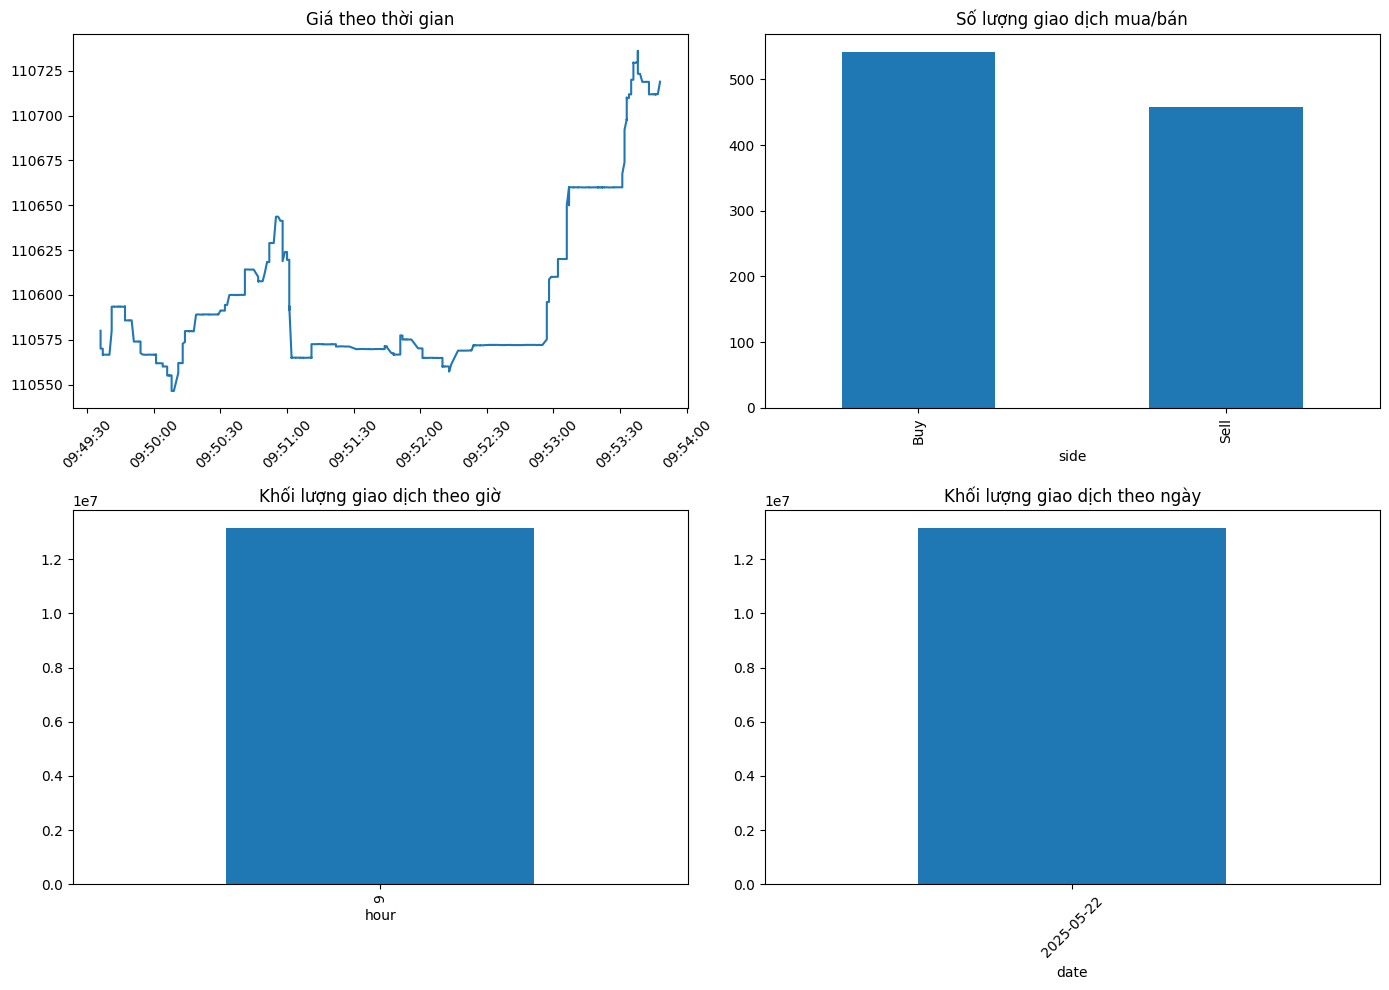


Thông tin thống kê:
Tổng số giao dịch: 1000
Giá trung bình: 110614.46
Khối lượng trung bình: 0.12
Giá trị giao dịch lớn nhất: 777483.04
Tổng giá trị giao dịch: 13142488.45


In [ ]:
# Ví dụ: Lấy dữ liệu giao dịch cho BTCUSDT trong 3 ngày gần đây
symbol = "BTCUSDT"
product_type = "usdt-futures"

# Thiết lập thời gian bắt đầu và kết thúc (3 ngày gần đây)
end_date = datetime.now()
start_date = end_date - timedelta(days=3)

print(f"Lấy dữ liệu từ {start_date} đến {end_date}")

# Lấy dữ liệu
transactions = get_transaction_history_by_period(
    symbol=symbol,
    product_type=product_type,
    start_date=start_date,
    end_date=end_date,
    limit=1000
)

# Xử lý dữ liệu
df = process_transaction_data(transactions)

# Kiểm tra tính hợp lệ của timestamp
valid_timestamps = check_timestamp_validity(df)
if not valid_timestamps:
    print("Sẽ tiếp tục với dữ liệu hiện có, nhưng cần kiểm tra lại định dạng timestamp trong API")
    
    # Thử sửa timestamps nếu không hợp lệ
    df = correct_timestamps(df)
    print("\nKiểm tra lại sau khi sửa:")
    valid_timestamps = check_timestamp_validity(df)

# Hiển thị vài dòng đầu tiên
print("\nDữ liệu giao dịch:")
display(df.head())

# Trực quan hóa dữ liệu
visualize_transaction_data(df)

# Lưu dữ liệu ra file CSV (nếu cần)
df.to_csv(f"{symbol}_{start_date.date()}_{end_date.date()}.csv", index=False)

## Phân tích nâng cao

Một số phân tích nâng cao hơn cho dữ liệu giao dịch

In [21]:
def advanced_analysis(df):
    """
    Thực hiện phân tích nâng cao cho dữ liệu giao dịch
    
    Tham số:
    df (DataFrame): DataFrame chứa dữ liệu giao dịch đã xử lý
    """
    if df.empty:
        print("Không có dữ liệu để phân tích")
        return
    
    # Tính phân phối kích thước giao dịch
    plt.figure(figsize=(14, 6))
    
    # Phân phối kích thước giao dịch theo bên mua/bán
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x='size', hue='side', kde=True, bins=20)
    plt.title('Phân phối kích thước giao dịch')
    
    # Biểu đồ giá theo thời gian với màu phân biệt mua/bán
    plt.subplot(1, 2, 2)
    sns.scatterplot(data=df, x='ts', y='price', hue='side', size='size', sizes=(10, 100), alpha=0.7)
    plt.title('Giá theo thời gian với kích thước giao dịch')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Phân tích xu hướng
    if len(df) > 10:
        # Tính giá trung bình theo giờ
        hourly_price = df.groupby(pd.Grouper(key='ts', freq='1H'))['price'].mean().reset_index()
        
        plt.figure(figsize=(12, 6))
        plt.plot(hourly_price['ts'], hourly_price['price'])
        plt.title('Giá trung bình theo giờ')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Phân tích tương quan giữa kích thước và giá
        correlation = df['price'].corr(df['size'])
        print(f"\nHệ số tương quan giữa giá và kích thước giao dịch: {correlation:.4f}")

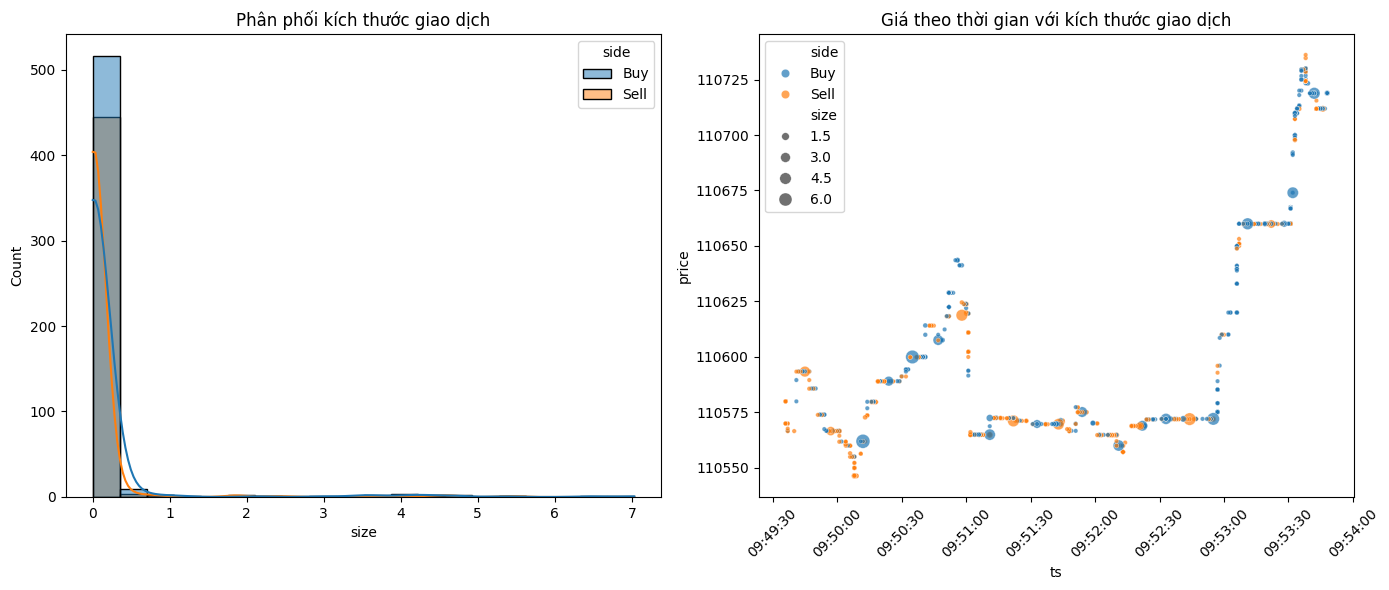

C:\Users\daong\AppData\Local\Temp\ipykernel_17440\3798634834.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_price = df.groupby(pd.Grouper(key='ts', freq='1H'))['price'].mean().reset_index()


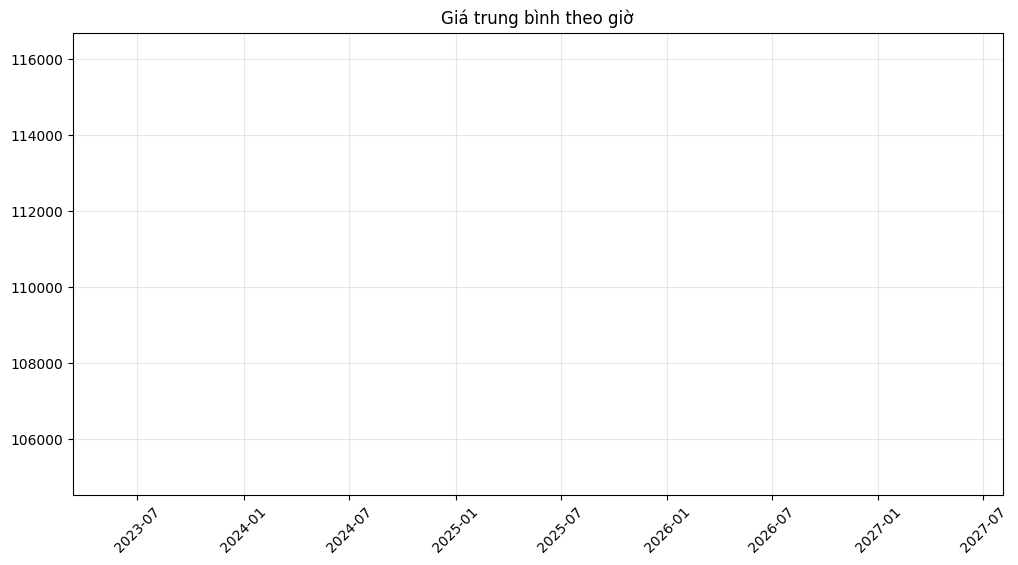


Hệ số tương quan giữa giá và kích thước giao dịch: -0.0524


In [22]:
# Sử dụng phân tích nâng cao trên dữ liệu đã lấy
if 'df' in locals() and not df.empty:
    advanced_analysis(df)

## Kết luận

Notebook này đã trình bày cách:
1. Kết nối đến API Bitget và lấy dữ liệu lịch sử giao dịch
2. Xử lý giới hạn thời gian 7 ngày bằng cách chia nhỏ yêu cầu
3. Chuyển đổi dữ liệu thành DataFrame để phân tích
4. Trực quan hóa và phân tích dữ liệu

Những bước tiếp theo có thể thực hiện:
- Thêm xác thực API nếu cần lấy dữ liệu cho tài khoản cụ thể
- Tối ưu quá trình lấy dữ liệu để xử lý nhiều cặp giao dịch
- Phân tích sâu hơn về mối quan hệ giữa khối lượng và giá